In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("winequality-red.csv", sep=";")
# print(df)
# print(df.isnull().sum())//print the number of null values in each column
# Fill missing values with column mean
df.fillna(df.mean(numeric_only=True), inplace=True)




In [16]:
#Extract the following columns as vectors: alcohol,citric acid.
alcohol = df["alcohol"]
citric_acid = df["citric acid"] 
print(type(alcohol))
print(alcohol.shape)

<class 'pandas.core.series.Series'>
(1599,)


In [18]:
#Select two features (e.g., alcohol and density) from the dataset and calculate the
#covariance matrix using np.cov(X.T), where X is the feature matrix consisting of the
#selected columns.

X = df[["alcohol", "density"]].values
print("Shape of X:", X.shape)
cov_matrix = np.cov(X.T)
print("Covariance Matrix:")
print(cov_matrix)

Shape of X: (1599, 2)
Covariance Matrix:
[[ 1.13564740e+00 -9.97951790e-04]
 [-9.97951790e-04  3.56202945e-06]]


In [21]:
#Perform eigen decomposition on the covariance matrix you computed in question 3.
#Identify and interpret the results:Identify the top 2 eigenvalues of the covariance
#matrix,Identify the corresponding eigenvectors.
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print("Eigenvalues:", eigenvalues)
print("Eigenvectors:", eigenvectors)
# Top 2 eigenvalues and corresponding eigenvectors
top_2_indices = np.argsort(eigenvalues)[::-1][:2]
top_2_eigenvalues = eigenvalues[top_2_indices]
top_2_eigenvectors = eigenvectors[:, top_2_indices]
print("Top 2 Eigenvalues:", top_2_eigenvalues)
print("Top 2 Eigenvectors:", top_2_eigenvectors)

Eigenvalues: [1.13564827e+00 2.68507580e-06]
Eigenvectors: [[ 9.99999614e-01  8.78753184e-04]
 [-8.78753184e-04  9.99999614e-01]]
Top 2 Eigenvalues: [1.13564827e+00 2.68507580e-06]
Top 2 Eigenvectors: [[ 9.99999614e-01  8.78753184e-04]
 [-8.78753184e-04  9.99999614e-01]]


Quality Counts:
quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64
The most common wine quality is: 5


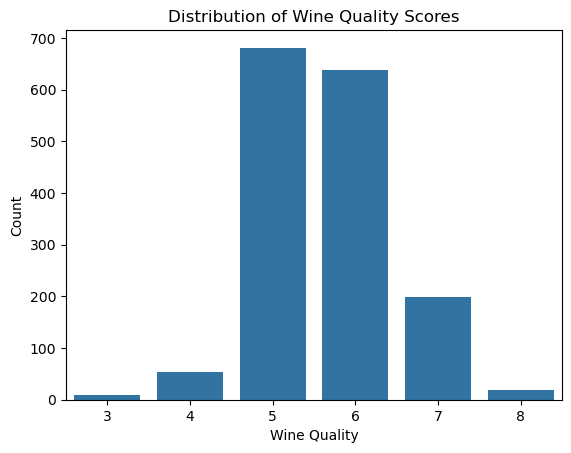

In [27]:
#Which wine quality is most common in the dataset? How can you interpret the
#distribution of wine quality scores?
import seaborn as sns
import matplotlib.pyplot as plt
# Count frequency of each quality score
quality_counts = df["quality"].value_counts()
print("Quality Counts:")
print(quality_counts)
# The most common quality is the one with the highest count
most_common_quality = quality_counts.index[0]
print(f"The most common wine quality is: {most_common_quality}")
sns.countplot( data=df, x="quality")
plt.title("Distribution of Wine Quality Scores")
plt.xlabel("Wine Quality")
plt.ylabel("Count")

plt.show()